# 10. 생성 AI 합성데이터 증강 — CTGAN · TVAE · SMOTE 전/후 비교

기획서 목표 1-b: *“생성 AI 모델(CTGAN 등)로 합성 데이터를 만들어 분류 성능 개선에 활용한다.”*

결과부터 말하면 **세 방식 모두 baseline 을 넘지 못했다.** 이 노트북은 그 반증 기록이다.

> **출처** — `원본/최종_3차_통합분석.ipynb` (코드 셀 **1개**, 29,946자)
>
> 원본은 `RUN_PART1`~`RUN_PART4` 플래그로 5개 파트를 한 셀에서 켜고 끄는 구조였다.
> 이 저장소는 그 플래그 경계를 그대로 살려 파트별 노트북으로 분리하고,
> **원본 실행 출력(표·그래프)을 해당 셀에 그대로 옮겨 붙였다.**
> 따라서 데이터가 없어도 결과를 볼 수 있고, 데이터가 있으면 그대로 재실행된다.



### 재현 조건

| 항목 | 값 |
|---|---|
| 입력 | `data/X_tr.parquet` · `X_va.parquet` · `y_tr.parquet` · `y_va.parquet` (**3차 전처리**) |
| 형상 | train `(96,140 × 58)` / valid `(23,860 × 58)` |
| 정상 클래스 | `12` (= `m`) |
| 모델 | `LGBMClassifier` · `n_estimators=300` · `class_weight="balanced"` · `random_state=42` |
| 학습 시간 | 약 13초 (4스레드) |

> `data/` 는 용량(141MB) 때문에 저장소에 포함하지 않았다 — `data/README.md` 참고.
> 아래 셀의 출력은 **원본 실행 결과 그대로**다.

> ⚠️ 원본의 `if RUN_PARTn:` 가드는 제거하고 들여쓰기를 풀었다.
> 파트별 노트북이므로 그 파트는 항상 실행된다 — **로직은 원본과 동일**하다.


## 0. 공통 설정 · 데이터 로드 · 모델 학습

다섯 개 노트북이 모두 이 블록으로 시작한다. 원본 통합 셀의 `[0]` 구획이다.


In [ ]:
# [0] 설정 · 데이터 로드 · 모델 학습 (여기부터 순서대로 실행)
import warnings, time, logging
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ===== 설정 =====
DATA_DIR = "../../data"        # 3차 전처리 parquet 폴더 (원본 실행 경로:
                               #   /mnt/c/Users/dkstj/Desktop/test_uv/3차 전처리 파일)
SEED = 42
LGBM_THREADS = 4
N_ESTIMATORS = 300             # 느리면 150~200 (수치가 달라짐)

RUN_PART1 = True               # 산출물 4종
RUN_COMPARE = True             # 모델 비교(한방 기본/임계값 · 2계층 기본/임계값) — 2계층 학습 포함
RUN_PART2 = True               # 비용기반 임계값
RUN_PART3 = True               # 규칙기반 + ML 결합
RUN_PART4 = True               # 생성 AI 합성데이터 증강 비교 (느림: sdv 필요)

LEAK_COLS = ["is_fraud", "fraud_type", "label", "y"]      # 정답 라벨 자동 제거
LOOKAHEAD_SUSPECT = ["Account_one_month_max_amount", "Account_one_month_std_dev",
                     "Account_dawn_one_month_max_amount", "Account_dawn_one_month_std_dev",
                     "Amount_vs_monthly_max_ratio"]        # 남아 있으면 경고만

# 비용 가정 (팀 합의값으로 교체)
FN_COST = 17_000_000
FP_SCENARIOS = {"A (FP 5k)": 5_000, "B (FP 10k)": 10_000, "C (FP 50k)": 50_000}
MACRO_MIN = 0.60               # 최종 채택 조건: Macro-F1 최소기준선
AMOUNT_COL = "Transaction_Amount_abs"

# 임계값 격자
THR_FULL = [0.9, 0.7, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01,
            0.005, 0.003, 0.002, 0.001, 0.0005, 0.0002, 0.0]
THR_BARS = [0.0, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.008, 0.01, 0.02, 0.03]
THR_COLLAPSE = [0.0, 0.00001, 0.00002, 0.00005, 0.0001, 0.00015, 0.0002]

SHAP_SAMPLE = 2000
TOP_FEATURES = 15

# [3] 하이브리드
RULE_MIN_SUPPORT = 15
PRECISION_SCAN = [0.85, 0.70, 0.50, 0.30]
CONT_Q_HI, CONT_Q_LO = [0.90, 0.95, 0.99], [0.01, 0.05, 0.10]
VERIFIED_COMPOSITES = ["large_deposit_and_remote_control", "unused_terminal_and_internet",
                       "limit_check_then_transfer", "suspended_recipient_and_withdrawal",
                       "new_recipient_and_large_amount", "weak_signal_composite_score"]
BOOST_WEIGHT = 0.30

# [4] 증강
TRAIN_SUBSAMPLE_NORMAL = 20000
TARGET_PER_CLASS = 500
GEN_EPOCHS = 300

LGBM_PARAMS = dict(n_estimators=N_ESTIMATORS, learning_rate=0.05, num_leaves=31,
                   subsample=0.9, colsample_bytree=0.9, class_weight="balanced",
                   random_state=SEED, n_jobs=LGBM_THREADS, verbose=-1)
lab = lambda i: chr(ord("a") + int(i))
np.random.seed(SEED)

In [ ]:
# ===== 표시 유틸 =====
def _setup_plt():
    import matplotlib
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
    import matplotlib.pyplot as plt
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
    matplotlib.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    return plt


def _table(df, caption=""):
    """VS Code/Jupyter면 표로 렌더링(출력 잘림 방지), 아니면 텍스트."""
    if caption:
        print(f"\n[{caption}]")
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            from IPython.display import display
            display(df); return
    except Exception:
        pass
    print(df.to_string(index=False))


def _head(title):
    print("\n" + "=" * 74); print(f" {title}"); print("=" * 74)

In [ ]:
# ===== 데이터 로드 =====
from lightgbm import LGBMClassifier
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

_d = Path(DATA_DIR)
X_tr = pd.read_parquet(_d / "X_tr.parquet").reset_index(drop=True)
X_va = pd.read_parquet(_d / "X_va.parquet").reset_index(drop=True)
y_tr = pd.read_parquet(_d / "y_tr.parquet").iloc[:, 0].astype(int).reset_index(drop=True)
y_va = pd.read_parquet(_d / "y_va.parquet").iloc[:, 0].astype(int).reset_index(drop=True)

_drop = [c for c in X_tr.columns if c.lower() in [s.lower() for s in LEAK_COLS]]
if _drop:
    print(f"[누수 제거] 정답 라벨 {_drop} 자동 제외")
    X_tr = X_tr.drop(columns=_drop); X_va = X_va.drop(columns=_drop)
_rest = [c for c in LOOKAHEAD_SUSPECT if c in X_tr.columns]
if _rest:
    print(f"[경고] look-ahead 의심 피처 잔존: {_rest}")
    print("       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요")

normal_idx = int(y_tr.value_counts().idxmax())
classes = sorted(y_tr.unique()); labels = [lab(c) for c in classes]
fcols = list(X_tr.columns)
amount = X_va[AMOUNT_COL].values.copy() if AMOUNT_COL in X_va.columns else None
basis = f"{X_tr.shape[1]} features | valid {len(y_va):,} rows (hold-out)"
basis_kr = f"피처 {X_tr.shape[1]}개 · valid 홀드아웃 {len(y_va):,}행 · 트리 {N_ESTIMATORS}"

_head(f"3차 전처리 통합 분석 — {basis_kr}")
print(f"[데이터] train {X_tr.shape} / valid {X_va.shape} | 정상={normal_idx}({lab(normal_idx)})")


# ===== 모델 학습 (1회, 전 파트 공유) =====
print("\n[학습] LightGBM 13-class ...")
_t = time.time()
model = LGBMClassifier(**LGBM_PARAMS).fit(X_tr, y_tr)
pred = model.predict(X_va)
macro = f1_score(y_va, pred, average="macro")
print(f"[검증] {round(time.time()-_t,1)}s | Macro-F1={macro:.4f} | "
      f"Weighted-F1={f1_score(y_va, pred, average='weighted'):.4f} | "
      f"Accuracy={accuracy_score(y_va, pred):.4f}")
print("  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단")

rep = classification_report(y_va, pred, labels=classes, target_names=labels,
                            output_dict=True, zero_division=0)
proba = model.predict_proba(X_va)
_cls = list(model.classes_); _npos = _cls.index(normal_idx)
risk = 1.0 - proba[:, _npos]                       # 위험점수 = 1 − P(정상)
_fp = proba.copy(); _fp[:, _npos] = -1.0
best_fraud = np.asarray(_cls)[_fp.argmax(axis=1)]  # 정상 제외 최고확률 유형
y_arr = np.asarray(y_va); yb = (y_arr != normal_idx)

[경고] look-ahead 의심 피처 잔존: ['Account_one_month_max_amount', 'Account_one_month_std_dev', 'Account_dawn_one_month_max_amount', 'Account_dawn_one_month_std_dev', 'Amount_vs_monthly_max_ratio']
       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요

 3차 전처리 통합 분석 — 피처 58개 · valid 홀드아웃 23,860행 · 트리 300
[데이터] train (96140, 58) / valid (23860, 58) | 정상=12(m)

[학습] LightGBM 13-class ...
[검증] 13.3s | Macro-F1=0.6138 | Weighted-F1=0.9942 | Accuracy=0.9949
  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단


위험점수 `risk = 1 − P(정상 m)` 기준 임계값 판정 헬퍼. 임계값을 쓰는 파트에서 공통으로 사용한다.


In [ ]:
def thr_predict(thr):
    """위험점수 ≥ thr → 사기(최고확률 유형), 아니면 정상."""
    p = np.full(len(y_arr), normal_idx); m = risk >= thr
    p[m] = best_fraud[m]; return p, m


def thr_scan(grid):
    rows = []
    for t in grid:
        p, m = thr_predict(t)
        fn = int((yb & ~m).sum()); fp = int((~yb & m).sum())
        r = dict(thr=t, macro=round(f1_score(y_arr, p, average="macro"), 4), FN=fn, FP=fp)
        for k, v in FP_SCENARIOS.items():
            r[k] = round((fn * FN_COST + fp * v) / 1e8, 3)
        if amount is not None:
            r["FN실제금액(억)"] = round(float(amount[yb & ~m].sum()) / 1e8, 2)
            r["FN고정값(억)"] = round(fn * FN_COST / 1e8, 2)
        rows.append(r)
    return pd.DataFrame(rows)

## 4. 증강 실험 설계

| 항목 | 값 | 이유 |
|---|---|---|
| 학습셋 | 정상 20,000 다운샘플 + 사기 942 = 20,942행 | 생성모델 학습 속도 |
| 목표 | 유형당 500건까지 생성 | 100건 → 500건 |
| epochs | 300 | CTGAN/TVAE 공통 |
| 검증 | **원본 valid 23,860행 그대로** | ⚠ 합성은 train 에만 |

> **평가 독립성** — 멘토가 지적한 "합성 데이터를 train 에만 넣고 검증은 실데이터로만 했는지"에 대한 답이다.
> `ev(Xt, yt, Xv, tag)` 는 항상 `y_va`(원본)로만 채점한다. 합성 데이터는 검증셋에 한 행도 들어가지 않는다.



 [4] 생성 AI 합성데이터 증강 전/후 비교
[증강 실험 학습셋] (20942, 58) (정상 다운샘플 20000)
  [baseline(증강 전)] Macro-F1=0.6230 | 사기 평균Recall=0.5783
  [CTGAN] 학습 (rows=942, epochs=300) ...


Sampling conditions: 100%|██████████| 5058/5058 [00:20<00:00, 246.38it/s]


  [+CTGAN(생성형)] Macro-F1=0.5302 | 사기 평균Recall=0.5112
  [TVAE] 학습 (rows=942, epochs=300) ...


Sampling conditions:  50%|████▉     | 2517/5058 [02:46<02:47, 15.14it/s] 


  [+TVAE(생성형)] Macro-F1=0.5859 | 사기 평균Recall=0.5603
  [SMOTE] 20942 → 26000행 (k_neighbors=5)
  [+SMOTE(규칙기반·참고)] Macro-F1=0.5764 | 사기 평균Recall=0.5502

[증강 방식별 비교 (동일 검증셋 · train만 증강)]


,방식,Macro_F1,사기평균Recall,ΔMacro_F1
0,baseline(증강 전),0.6230,0.5783,0.0000
1,+CTGAN(생성형),0.5302,0.5112,-0.0928
2,+TVAE(생성형),0.5859,0.5603,-0.0371
3,+SMOTE(규칙기반·참고),0.5764,0.5502,-0.0466



[결론] 최고: baseline(증강 전) (Macro-F1 0.623)
  → 어떤 증강도 baseline을 못 넘음: 유형당 표본이 적어(few-shot) 생성모델도 한계.
  → 증강 미채택. 성능 개선은 피처 품질(전처리) 쪽이 우선.
  ※ SMOTE는 규칙기반이라 DACON 최종제출 불가(참고치). CTGAN/TVAE만 제출 후보.


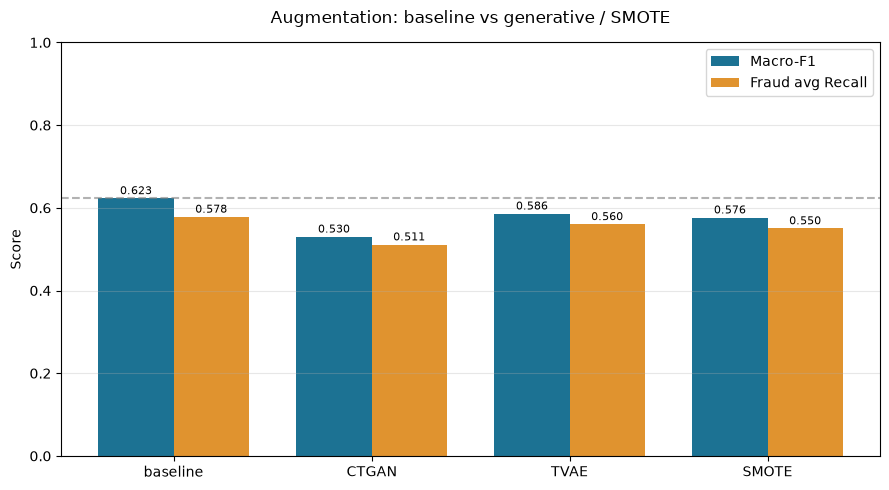

In [ ]:
_head("[4] 생성 AI 합성데이터 증강 전/후 비교")
plt = _setup_plt()

# 정상 다운샘플(속도) — 증강 실험 전용 학습셋
idx_n = y_tr.index[y_tr == normal_idx]
if len(idx_n) > TRAIN_SUBSAMPLE_NORMAL:
    keep = y_tr.index[y_tr != normal_idx].union(
        pd.Index(np.random.RandomState(SEED).choice(idx_n, TRAIN_SUBSAMPLE_NORMAL, replace=False)))
    Xa0 = X_tr.loc[keep].reset_index(drop=True); ya0 = y_tr.loc[keep].reset_index(drop=True)
else:
    Xa0, ya0 = X_tr, y_tr
print(f"[증강 실험 학습셋] {Xa0.shape} (정상 다운샘플 {TRAIN_SUBSAMPLE_NORMAL})")

def ev(Xt, yt, Xv, tag):
    m = LGBMClassifier(**LGBM_PARAMS).fit(Xt, yt)
    p = m.predict(Xv)
    mac = f1_score(y_va, p, average="macro")
    rp = classification_report(y_va, p, labels=classes, target_names=labels,
                               output_dict=True, zero_division=0)
    fl_ = [l for l in labels if l != lab(normal_idx)]
    rec = float(np.mean([rp[l]["recall"] for l in fl_]))
    print(f"  [{tag}] Macro-F1={mac:.4f} | 사기 평균Recall={rec:.4f}")
    return {"방식": tag, "Macro_F1": round(mac, 4), "사기평균Recall": round(rec, 4)}

res = [ev(Xa0, ya0, X_va, "baseline(증강 전)")]

def aug_sdv(kind):
    try:
        from sdv.metadata import SingleTableMetadata
        from sdv.sampling import Condition
        if kind == "CTGAN":
            from sdv.single_table import CTGANSynthesizer as S
            kw = dict(epochs=GEN_EPOCHS, verbose=False)
        else:
            from sdv.single_table import TVAESynthesizer as S
            kw = dict(epochs=GEN_EPOCHS)
    except Exception as e:
        print(f"  [{kind} 건너뜀] sdv 미설치/오류: {e}"); return None
    fm = (ya0 != normal_idx).values
    df = Xa0[fm].copy(); df["y"] = ya0[fm].values
    meta = SingleTableMetadata(); meta.detect_from_dataframe(df)
    for c in fcols: meta.update_column(c, sdtype="numerical")
    meta.update_column("y", sdtype="categorical")
    print(f"  [{kind}] 학습 (rows={len(df)}, epochs={GEN_EPOCHS}) ...")
    syn = S(meta, **kw); syn.fit(df)
    conds = []
    for c in sorted(pd.Series(ya0[fm]).unique()):
        need = max(TARGET_PER_CLASS - int((ya0[fm] == c).sum()), 0)
        if need > 0: conds.append(Condition(num_rows=need, column_values={"y": int(c)}))
    gen = syn.sample_from_conditions(conds)
    gX = gen.drop(columns=["y"])[fcols].apply(pd.to_numeric, errors="coerce")
    return (pd.concat([Xa0, gX], ignore_index=True),
            pd.concat([ya0, pd.Series(gen["y"].astype(int).values)], ignore_index=True))

for kind in ["CTGAN", "TVAE"]:
    out = aug_sdv(kind)
    if out: res.append(ev(out[0], out[1], X_va, f"+{kind}(생성형)"))

try:
    from imblearn.over_sampling import SMOTE
    from sklearn.impute import SimpleImputer
    from collections import Counter
    imp = SimpleImputer(strategy="median").fit(Xa0)
    Xi = pd.DataFrame(imp.transform(Xa0), columns=fcols)
    Xvi = pd.DataFrame(imp.transform(X_va), columns=fcols)
    cnt = Counter(np.asarray(ya0))
    strat = {c: TARGET_PER_CLASS for c in cnt if c != normal_idx and cnt[c] < TARGET_PER_CLASS}
    k = max(1, min(5, min(cnt[c] for c in strat) - 1))
    Xr, yr = SMOTE(sampling_strategy=strat, k_neighbors=k, random_state=SEED).fit_resample(Xi, np.asarray(ya0))
    print(f"  [SMOTE] {len(Xi)} → {len(Xr)}행 (k_neighbors={k})")
    res.append(ev(pd.DataFrame(Xr, columns=fcols), pd.Series(yr), Xvi, "+SMOTE(규칙기반·참고)"))
except Exception as e:
    print(f"  [SMOTE 건너뜀] {e}  (pip install imbalanced-learn)")

tbl = pd.DataFrame(res)
tbl["ΔMacro_F1"] = (tbl["Macro_F1"] - tbl.loc[0, "Macro_F1"]).round(4)
_table(tbl, "증강 방식별 비교 (동일 검증셋 · train만 증강)")
bestr = tbl.loc[tbl["Macro_F1"].idxmax()]
print(f"\n[결론] 최고: {bestr['방식']} (Macro-F1 {bestr['Macro_F1']})")
if bestr["방식"].startswith("baseline"):
    print("  → 어떤 증강도 baseline을 못 넘음: 유형당 표본이 적어(few-shot) 생성모델도 한계.")
    print("  → 증강 미채택. 성능 개선은 피처 품질(전처리) 쪽이 우선.")
print("  ※ SMOTE는 규칙기반이라 DACON 최종제출 불가(참고치). CTGAN/TVAE만 제출 후보.")

if len(res) >= 2:
    x = np.arange(len(tbl)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - w/2, tbl["Macro_F1"], w, label="Macro-F1", color="#1C7293")
    ax.bar(x + w/2, tbl["사기평균Recall"], w, label="Fraud avg Recall", color="#E0932F")
    for i in range(len(tbl)):
        ax.text(i - w/2, tbl["Macro_F1"][i] + .01, f"{tbl['Macro_F1'][i]:.3f}", ha="center", fontsize=8)
        ax.text(i + w/2, tbl["사기평균Recall"][i] + .01, f"{tbl['사기평균Recall'][i]:.3f}", ha="center", fontsize=8)
    ax.axhline(tbl.loc[0, "Macro_F1"], ls="--", color="gray", alpha=.6)
    ax.set_xticks(x); ax.set_xticklabels(["baseline", "CTGAN", "TVAE", "SMOTE"][:len(tbl)])
    ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.legend(); ax.grid(axis="y", alpha=.3)
    ax.set_title("Augmentation: baseline vs generative / SMOTE", pad=14)
    fig.tight_layout(); plt.show()

### 결론 — 증강 미채택

| 방식 | Macro-F1 | 사기 평균 Recall | ΔMacro-F1 |
|---|---|---|---|
| **baseline (증강 전)** | **0.6230** | 0.5783 | — |
| +CTGAN | 0.5302 | 0.5112 | **−0.0928** |
| +TVAE | 0.5859 | 0.5603 | −0.0371 |
| +SMOTE (참고) | 0.5764 | 0.5502 | −0.0466 |

세 방식 **전부 성능을 떨어뜨렸다.** 원인은 few-shot 한계다 —
생성모델이 학습할 원본이 유형당 100건뿐이라, 만들어낸 500건은 원 분포를 재현하는 대신
**100건의 우연한 특성을 증폭**한다. CTGAN 이 가장 크게 무너진 것(−0.0928)이 그 방증이다.

> **멘토 피드백에 대한 답이기도 하다.** "유형당 100건은 극도로 작은 표본이라 우연 변동에 취약하니
> 대안이 필요하다"는 지적에 팀은 CTGAN 을 대안으로 제시했지만, 실측 결과
> **합성 증강은 few-shot 문제의 해법이 아니었다.** 개선은 피처 품질(전처리) 쪽이 우선이다.

> ※ SMOTE 는 규칙 기반 보간이라 DACON 최종 제출 대상이 아니다(참고치).
> 생성형(CTGAN/TVAE)만 제출 후보였다.


---

## 부록 — 원본 통합 실행의 `[5] 최종 요약`

아래는 **다섯 파트를 한 번에 실행했을 때** 마지막에 출력되던 요약이다.
파트별로 분리한 이 저장소에서는 어느 한 노트북도 단독으로 이 출력을 낼 수 없어
(전 파트의 변수를 동시에 참조한다) **원본 출력을 그대로 인용**해 둔다.

```text
==========================================================================
 [5] 최종 요약
==========================================================================
  기준        : 피처 58개 · valid 홀드아웃 23,860행 · 트리 300
  최종 모델   : LightGBM 13-class (한방) · Macro-F1 = 0.6138
  모델 비교   : 최고 = 한방 + 임계값 조정 (임계값 0.03) · Macro-F1 0.6395
                · 한방 13-class (기본 argmax)    임계값       - → 0.6138
                · 한방 + 임계값 조정                임계값    0.03 → 0.6395
                · 2계층 TwoStage (기본 0.5)      임계값     0.5 → 0.6105
                · 2계층 + 임계값 조정               임계값     0.5 → 0.6105
  채택 임계값 : 0.005 (Macro-F1 0.6030, 미탐 27, 오탐 69, 비용 4.62억)
  성능 최고점 : 0.03 (Macro-F1 0.6395)
  하이브리드  : 규칙 결합 순이득 없음 → ML 중심 유지
  생성 증강   : 최고 baseline(증강 전) → 증강 이득 제한적
  ⚠️ look-ahead 잔존: 5개 (as-of 재설계 후 재측정 필요)

[완료] 통합 분석 종료.
```
